In [18]:
import pandas as pd
tips = pd.read_csv('/content/tips (1).csv')
display(tips.head())

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Advanced Data Visualization

Advanced Visualizations allows us to see patterns that basic charts might hide such as the "density" of data or the hidden correlations between dozens of variables at once.

Here are the most common advanced plots used in data science.

## Box Plot and Violin Plot

While both show the distribution of data, they provide different levels of detail.

Box Plot: Focuses on the "summary statistics." It shows the Median, Quartiles, and Outliers (points that fall outside the typical range).

Violin Plot: Combines a Box Plot with a Kernel Density Estimate (KDE). The "fat" part of the violin shows where most data points are concentrated.

Download data from [data link ](https://www.kaggle.com/datasets/ranjeetjain3/seaborn-tips-dataset)

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using a built-in dataset (tips)
tips = sns.load_dataset("tips")
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


/tmp/ipykernel_3550/4237523397.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="time", y="tip", data=tips, palette="Set2")


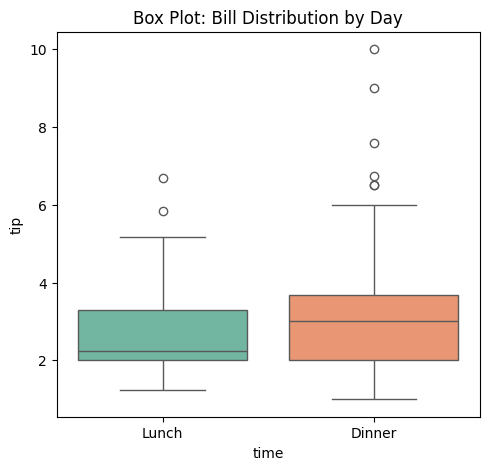

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using a built-in dataset (tips)
tips = sns.load_dataset("tips")

plt.figure(figsize=(12, 5))

# Box Plot
plt.subplot(1, 2, 1)
sns.boxplot(x="time", y="tip", data=tips, palette="Set2")
plt.title("Box Plot: Bill Distribution by Day")


plt.show()

/tmp/ipykernel_5539/526349457.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="day", y="total_bill", data=tips, palette="Pastel1")


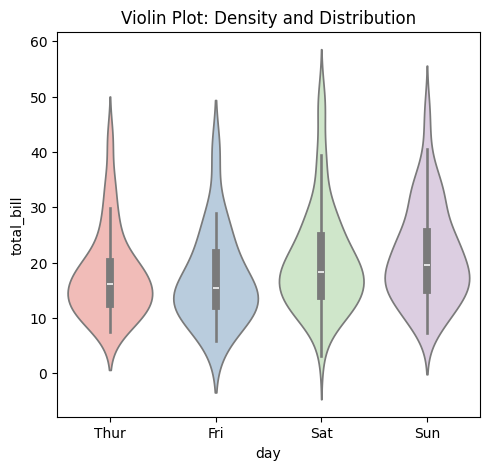

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using a built-in dataset (tips)
tips = sns.load_dataset("tips")

plt.figure(figsize=(12, 5))


# Violin Plot
plt.subplot(1, 2, 2)
sns.violinplot(x="day", y="total_bill", data=tips, palette="Pastel1")
plt.title("Violin Plot: Density and Distribution")

plt.show()

## Heatmap
A Heatmap is a graphical representation of data where individual values contained in a matrix are represented as colors. It is most commonly used to show a Correlation Matrix—helping you see which variables move together.

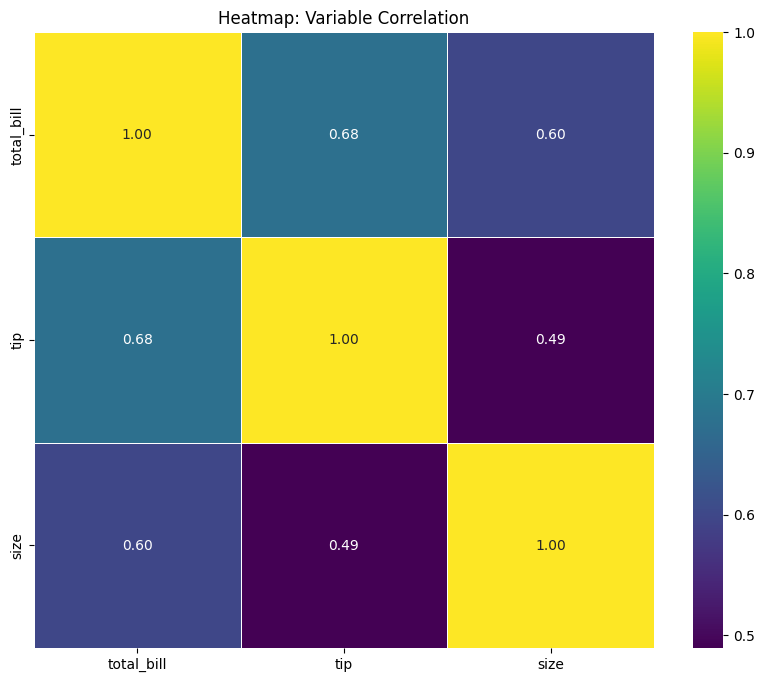

In [33]:
# Computing correlation between numerical variables
corr = tips.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title("Heatmap: Variable Correlation")
plt.show()

## Pair Plot
When we have a dataset with many columns, a Pair Plot is the fastest way to explore every possible relationship. It creates a grid of scatter plots for every pair of variables and histograms for the variables themselves.

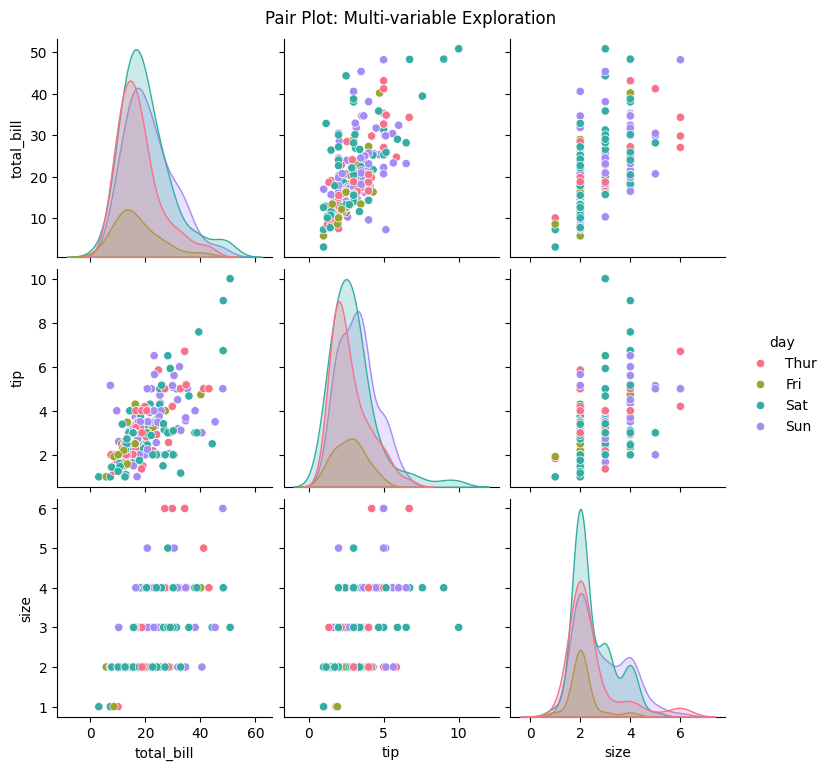

In [34]:
# Pair Plot shows relationships across the entire dataset
sns.pairplot(tips, hue="day", palette="husl")
plt.suptitle("Pair Plot: Multi-variable Exploration", y=1.02)
plt.show()

## Joint Plot
A Joint Plot allows you to look at two variables simultaneously, showing both their Scatter Plot (relationship) and their Histograms (marginal distributions) on the sides.

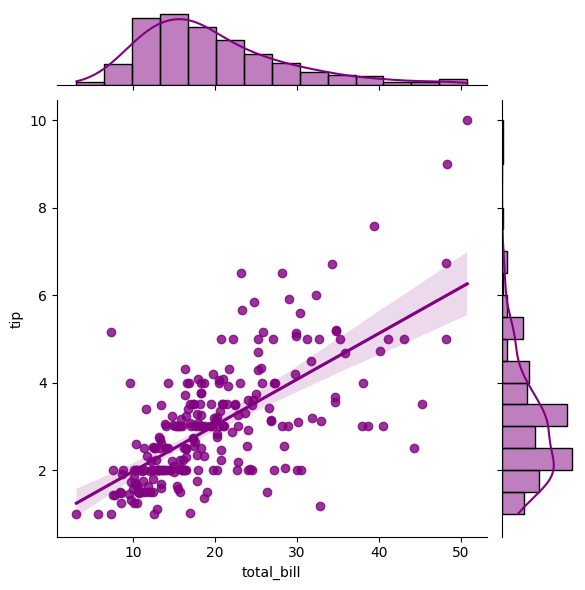

In [ ]:
# Analyzing Total Bill vs Tip
sns.jointplot(x="total_bill", y="tip", data=tips, kind="reg", color="purple")
plt.show()

## Radar (Spider) Chart
Radar charts are used to compare multiple quantitative variables for a single item. They are popular in sports (player stats) or business (comparing product features).

/tmp/ipykernel_5539/1671405259.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  radar_df = tips.groupby('time')[['total_bill', 'tip', 'size']].mean()


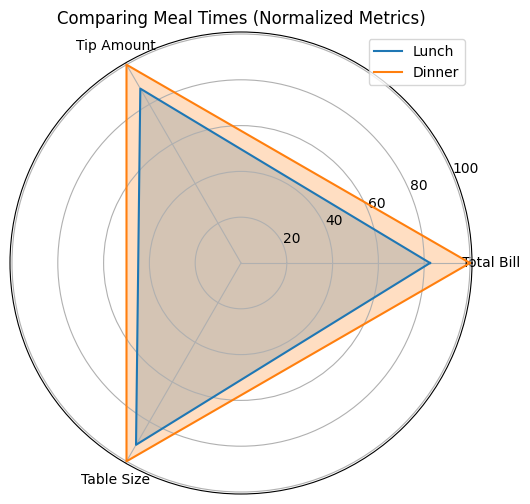

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Aggregating data for Radar Chart
radar_df = tips.groupby('time')[['total_bill', 'tip', 'size']].mean()
# Normalize data to a 0-100 scale for better visualization
radar_df = (radar_df / radar_df.max()) * 100

categories = ['Total Bill', 'Tip Amount', 'Table Size']
values_lunch = radar_df.loc['Lunch'].tolist()
values_dinner = radar_df.loc['Dinner'].tolist()

# Close the loop
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
values_lunch += values_lunch[:1]
values_dinner += values_dinner[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values_lunch, label='Lunch')
ax.fill(angles, values_lunch, alpha=0.25)
ax.plot(angles, values_dinner, label='Dinner')
ax.fill(angles, values_dinner, alpha=0.25)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
plt.legend()
plt.title("Comparing Meal Times (Normalized Metrics)")
plt.show()

## Bubble Chart
We can use a scatter plot where the Total Bill is the x-axis, the Tip is the y-axis, and the Size of the table determines the size of the bubble. This shows if larger groups leave larger tips.

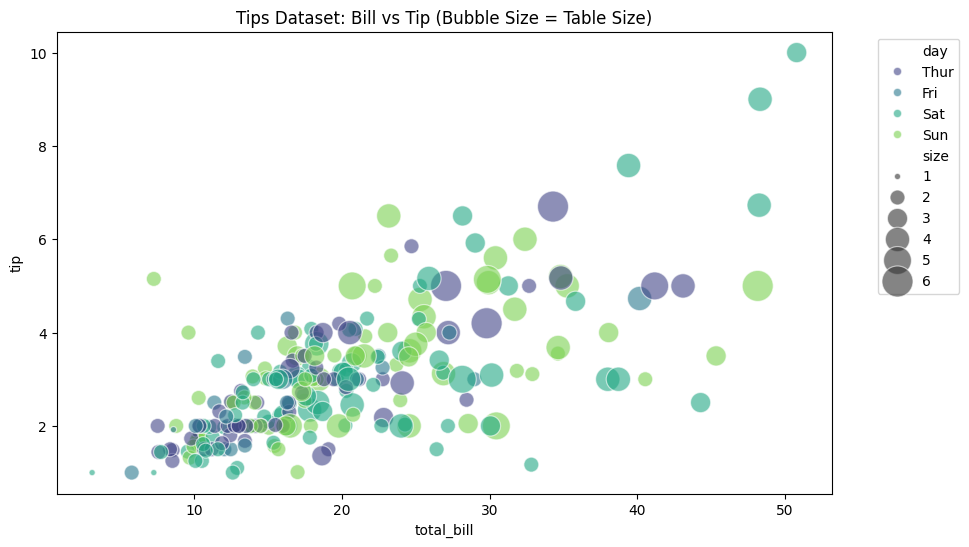

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=tips, x="total_bill", y="tip",
                size="size", hue="day", alpha=0.6,
                sizes=(20, 500), palette="viridis")

plt.title("Tips Dataset: Bill vs Tip (Bubble Size = Table Size)")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

## Parallel Coordinates Plot
This is great for seeing how an individual "Tip" event flows through the different numerical categories. We will color the lines by the Day to see if weekends behave differently than weekdays.

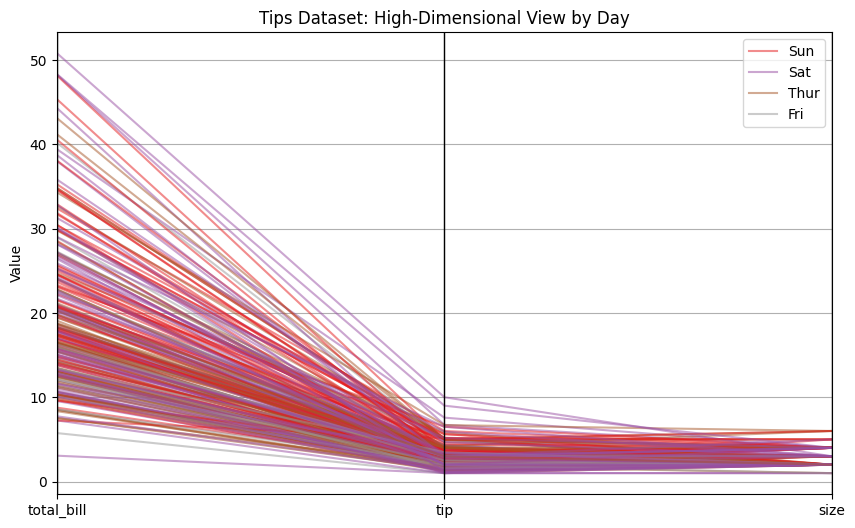

In [ ]:
import pandas as pd
from pandas.plotting import parallel_coordinates

# Selecting numerical columns and the class we want to color by
cols = ['total_bill', 'tip', 'size', 'day']
df_parallel = tips[cols]

plt.figure(figsize=(10, 6))
parallel_coordinates(df_parallel, 'day', colormap='Set1', alpha=0.5)
plt.title("Tips Dataset: High-Dimensional View by Day")
plt.ylabel("Value")
plt.show()

## Sunburst Chart
Using the tips data, we can create a hierarchy: Day → Time → Sex. This shows the proportion of the total revenue coming from each group.

In [ ]:
import plotly.express as px

# We use Plotly for Sunburst as it handles hierarchy natively
fig = px.sunburst(tips, path=['day', 'time', 'sex'], values='total_bill',
                  color='total_bill', color_continuous_scale='RdBu')

fig.update_layout(title_text="Revenue Hierarchy: Day > Time > Gender")
fig.show()

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfg = df.groupby(path[i:]).agg(agg_f)
/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfg = df.groupby(path[i:]).agg(agg_f)
/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  

# Bar Chart


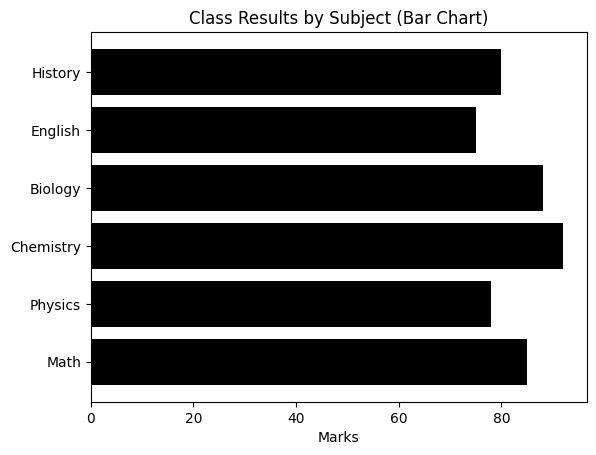

In [5]:
import matplotlib.pyplot as plt
subjects = ['Math', 'Physics', 'Chemistry', 'Biology',
'English', 'History']
results = [85, 78, 92, 88, 75, 80]
# Sorting for better readability (Ascending/Descending)
subjects, results = zip(*sorted(zip(subjects, results),
key=lambda x: x[1]))
plt.barh(subjects, results, color='')
plt.title('Class Results by Subject (Bar Chart)')
plt.xlabel('Marks')
plt.show()

# Pie Chart

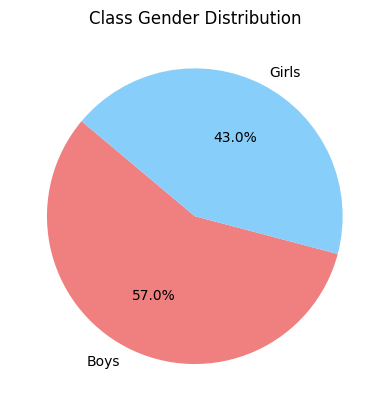

In [6]:
import matplotlib.pyplot as plt
labels = ['Boys', 'Girls']
sizes = [57, 43]
colors = ['lightcoral', 'lightskyblue']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors,
startangle=140)
plt.title('Class Gender Distribution')
plt.show()

# Histogram

Text(0.5, 1.0, 'Distribution of Marks')

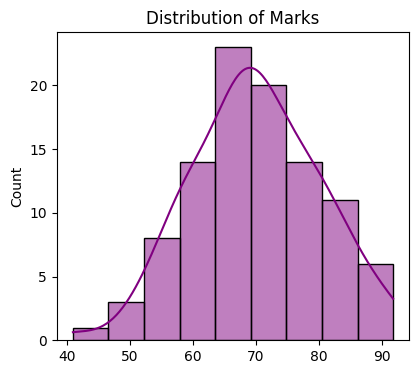

In [7]:
import seaborn as sns
import numpy as np
# Generating dummy student marks
marks = np.random.normal(70, 10, 100)
# Histogram for Distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(marks, kde=True, color='purple')
plt.title('Distribution of Marks')

# Box Plot


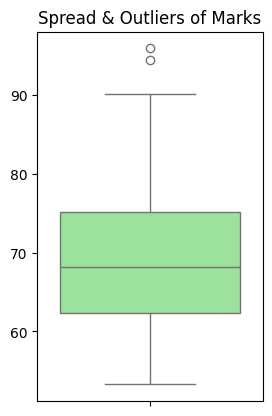

In [8]:
import seaborn as sns
import numpy as np
# Generating dummy student marks
marks = np.random.normal(70, 10, 100)
# Box Plot for Outliers/Spread
plt.subplot(1, 2, 2)
sns.boxplot(y=marks, color='lightgreen')
plt.title('Spread & Outliers of Marks')
plt.show()

# Line Chart


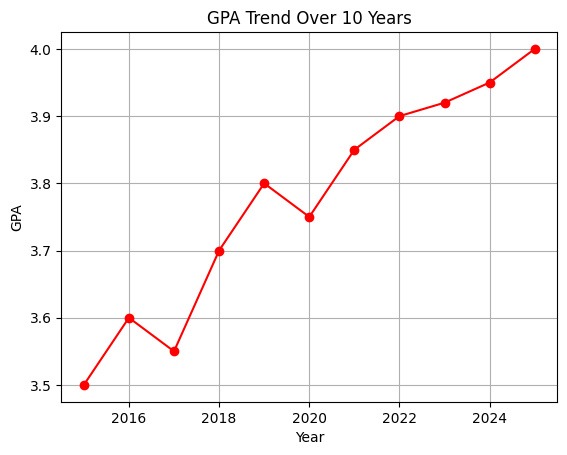

In [9]:
years = list(range(2015, 2026))
gpa = [3.5, 3.6, 3.55, 3.7, 3.8, 3.75, 3.85, 3.9, 3.92, 3.95,
4.0]
plt.plot(years, gpa, marker='o', linestyle='-', color='red')
plt.title('GPA Trend Over 10 Years')
plt.xlabel('Year')
plt.ylabel('GPA')
plt.grid(True)
plt.show()

# Area Chart

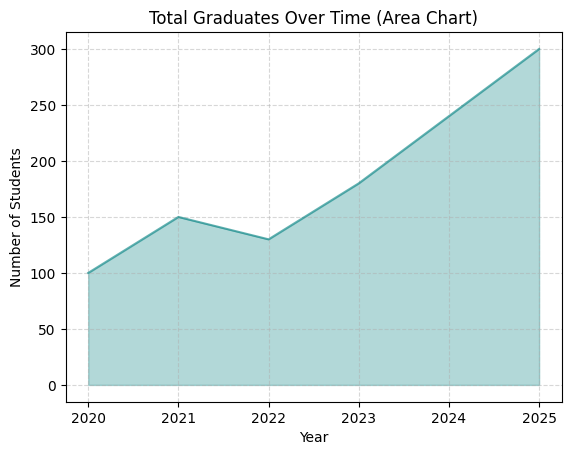

In [11]:
import matplotlib.pyplot as plt
years = [2020, 2021, 2022, 2023, 2024, 2025]
graduates = [100, 150, 130, 180, 240, 300]
# Create the plot

plt.plot(years, graduates, color="teal", alpha=0.6) # The line
plt.fill_between(years, graduates, color="teal", alpha=0.3) #The "Area"

plt.title("Total Graduates Over Time (Area Chart)")
plt.xlabel("Year")
plt.ylabel("Number of Students")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Relationship

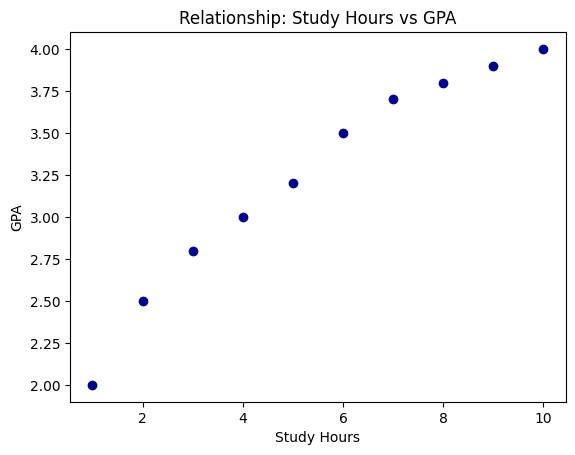

In [12]:
study_hours = [2, 3, 5, 1, 8, 7, 6, 4, 9, 10]
gpa_obtained = [2.5, 2.8, 3.2, 2.0, 3.8, 3.7, 3.5, 3.0,3.9, 4.0]
plt.scatter(study_hours, gpa_obtained, color='darkblue')
plt.title('Relationship: Study Hours vs GPA')
plt.xlabel('Study Hours')
plt.ylabel('GPA')
plt.show()